This document contains all the code used in partial fulfillment of the CSCI 111 (WX1) Final Project.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

### Introduction and Preliminary Exploration

We begin by specifying the dataset that will be used. Particularly, the group will use the dataset titled ["Estimation of Obesity Levels Based On Eating Habits and Physical Condition"](https://doi.org/10.24432/C5H31Z) prepared by Fabio Mendoza Palechor and Alexis de la Hoz Manotas, and accessed through UC Irvine's Machine Learning Repository.  

The dataset contains some factors pertaining to the eating habit and physical condition of individuals from Mexico, Peru and Columbia and their associated obesity level. There are **2111 instances** (23% are anonymous users on a web platform, and 77% are generated synthetically using the Weka tool and the SMOTE filter), and **16 features** (whose labels and descriptions are summarized in Table 1).

To collect the data, we have the option of downloading it locally or connecting to UCI's API. We do the latter for completion, and store the features in `X` and the labels in `y`.

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition = fetch_ucirepo(id=544)

# data (as pandas dataframes)
X = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.features
y = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.targets

X.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation


In [ ]:
# variable information
estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.variables.style.set_caption("Table 1. Variable labels and descriptions.")

,name,role,type,demographic,description,units,missing_values
0,Gender,Feature,Categorical,Gender,None,None,no
1,Age,Feature,Continuous,Age,None,None,no
2,Height,Feature,Continuous,None,None,None,no
3,Weight,Feature,Continuous,None,None,None,no
4,family_history_with_overweight,Feature,Binary,None,Has a family member suffered or suffers from overweight?,None,no
5,FAVC,Feature,Binary,None,Do you eat high caloric food frequently?,None,no
6,FCVC,Feature,Integer,None,Do you usually eat vegetables in your meals?,None,no
7,NCP,Feature,Continuous,None,How many main meals do you have daily?,None,no
8,CAEC,Feature,Categorical,None,Do you eat any food between meals?,None,no
9,SMOKE,Feature,Binary,None,Do you smoke?,None,no


Observe that the dataset can be partitioned into 7 classes based on the feature `NObeyesdad` (Obesity level). Figure 1 below presents a histogram based on the frequency of each class to give us idea about the distribution of the dataset.

We find that each class is fairly evenly represented (the distribution seems uniform with only slight variations). This is expected knowing that SMOTE filter was used to generate a portion of the dataset.

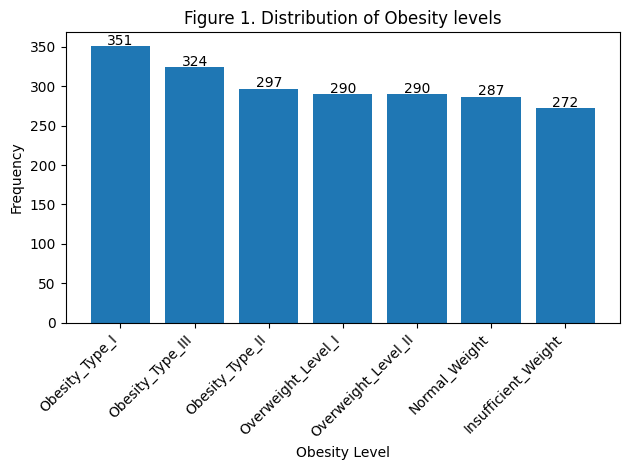

In [ ]:
obesity_counts = y["NObeyesdad"].value_counts()
bar = plt.bar(obesity_counts.index, obesity_counts.values)

# formating
plt.title('Figure 1. Distribution of Obesity levels')
plt.ylabel('Frequency')
plt.xlabel('Obesity Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.bar_label(bar, padding=-1, size=10)

plt.show()

After these preliminary exploration, we begin the process of building the machine learning model with the following question: **Given a person's eating habits and physical condition (refer to the features in Table 1), what is their obesity level?**

Particularly, we aim to train models that take-in the habits and conditions of an individual and classify them into one of the seven obesity levels. We are performing a classification task on a labelled dataset, so we need models that are fit to perform **supervised classification**.

This project presents two such models using **Logistic Regression** and **Decision Trees**, and evaluates them for comparison.

### MODEL 1: Using Logistic Regression

We begin by recalling that logistic regression attempts to fit the dataset of size $n$, $\{ (\vec{\mathbf{x}}_i, y_i) \}_{i=1}^n$, to the following model:
$$ h(x) = \frac{1}{1 + e^{\vec{\mathbf{w}}^{\top}\vec{\mathbf{x}}}} $$  

Thus we need the values of $\vec{\mathbf{x}}$ to be numeric. Looking at our `X`, this is clearly not the case since we have binary and categorical data. Thus, our first step is to transform these categorical values into numerical form.

In transforming the values of the columns in `cat_cols`, we note that we aim to prevent suggesting an ordinal relationship between the values. For example, if we naively set the mapping for `CALS` (how often the person drinks alcohol) as: `no` $\to$ `0` and `sometimes` $\to$ `1`, `often` $\to$ `2`, and `always` $\to$ `3`, our model might infer a heirarchy between these values, leading to inaccurate results. Thus, to prevent this, we use **one-hot-encoding** which creates a column for each potential value of a cell, and marks the cell as `1` if the column corresponds to the value of the cell and `0` otherwise. For the columns in `binary_cols`, this is simpler as `yes` and `no` can be mapper to `1` and `0`, respectively.

Observe that by employing one-hot encoding, we increase the number of columns for `X_cont`. In our case, this seems unavoidable, but we can implement feature-selecton later (particularly through regularization) to lessen this number in our final model.

In [ ]:
# Classify the features
binary_cols = ['Gender', "family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
numeric_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]
cat_cols = ["CAEC", "CALC", "MTRANS"]

# Encode the non-numeric features
for col in binary_cols:
  X[col] = LabelEncoder().fit_transform(X[col])

ct = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)],
    remainder='passthrough'
)

X_cont = ct.fit_transform(X).copy()
y_arr = y["NObeyesdad"].to_numpy()
features = ct.get_feature_names_out()

print(f"original size: {X.shape}")
print(f"new size: {X_cont.shape}")
X_cont

original size: (2111, 16)
new size: (2111, 23)


/tmp/ipython-input-3953434179.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = LabelEncoder().fit_transform(X[col])
/tmp/ipython-input-3953434179.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = LabelEncoder().fit_transform(X[col])
/tmp/ipython-input-3953434179.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

array([[0.      , 1.      , 0.      , ..., 0.      , 0.      , 1.      ],
       [0.      , 1.      , 0.      , ..., 1.      , 3.      , 0.      ],
       [0.      , 1.      , 0.      , ..., 0.      , 2.      , 1.      ],
       ...,
       [0.      , 1.      , 0.      , ..., 0.      , 1.414209, 0.646288],
       [0.      , 1.      , 0.      , ..., 0.      , 1.139107, 0.586035],
       [0.      , 1.      , 0.      , ..., 0.      , 1.026452, 0.714137]])

Next, we split the model between training and testing sets. The rule of thumb is to pick 20% of the dataset as testing points, and the rest as training points, but this is an arbitrary rule. Note as well that throughout this section, we set `random_seed=67` when appropriate for reproducibility.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cont, y_arr, test_size=0.2, random_state=67
)

Finally, we are ready to implement the model. Note that we will also add a regularization term to the loss function to help lessen the values of the weights (and in turn help for feature selection). Currently, we are unsure about the strength of regulatization ($\lambda$ in the general case, but it appears to be $1/C$ in `sklearn`'s implementation), and the regularization term itself (if we'll use L1 or L2 regularization) that would lead to the least error. Thus, we use `sklearn`'s `GridSearchCV` to loop through potential values for `C` and regularizatin terms, and identify the one with the best score according to the accuracy metric. The suffix `CV` also refers to cross-fold validation, which further separates the data into $n$ "folds" and uses each fold as a testing set (and the rest as training set). Since the scores are averaged, we become more confident that the score for a model accurately measures its performance. We follow the common $n = 5$.

Note that we also scale the values of `X` before proceeding with the model to ensure that bigger values do not greatly skew the weights we calculate. For cleanliness of code, we use `pipeline` to chain the scaling and model implementation parts.

In [ ]:
modelLR = LogisticRegression(random_state=67)
pipelineLR = Pipeline([
    ('scaler', StandardScaler()),
    ('model', modelLR)
])

In [ ]:
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga']
}

LR_grid_search = GridSearchCV(
    pipelineLR,
    param_grid,
    cv=5,
)

LR_grid_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(random_state=67))]),
             param_grid={'model__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'model__penalty': ['l1', 'l2'],
                         'model__solver': ['liblinear', 'saga']})

We now find that the best model will involve an L1 penalty term with regularization strength $\lambda = 1$. Observe that the L1 term is beneficial for us since it is possible for this term to lead to a weight with value 0, thus suggesting that the feature associated does not have an effect on the decision boundary. (This helps with feature selection.)

When tested against our original testing data, `y_test`, our model achieved an **accuracy score of 0.90**. Our group believes that this is a sufficient score. Of greater importance to us is the recall score for each class, as recorded in Table 2.1. Observe that for this model, almost all of the classes have a recall score greater than or equal to 0.85 (except for `Normal_Weight`). The recall score is given by:
$$ \frac{\text{true positives}}{\text{true positives} + \text{false negatives}}, $$
which tells us that the model is generally good at identifying true positives. Since the model predicts the obesity level (which might be applied in programs that aim to prevent obesity), we hold that it is better to misclassify individuals into the problematic classes (i.e. not `Normal_Weight`) than to misclassify a healthy individual to a problematic class. In the former case, for example, we can apply the obesity prevention program to the individual even if they do not need it.

In [ ]:
print(LR_grid_search.best_score_)
print(LR_grid_search.best_estimator_)

0.8590241075974927
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=1, penalty='l1', random_state=67,
                                    solver='saga'))])


In [ ]:
y_pred = LR_grid_search.predict(X_test)
print(f"Table 2.1. Summary of the score of the best estimator using Logistic Regression.\n\n{classification_report(y_test, y_pred)}")

Table 2.1. Summary of the score of the best estimator using Logistic Regression.

                     precision    recall  f1-score   support

Insufficient_Weight       0.79      0.96      0.87        51
      Normal_Weight       0.89      0.72      0.80        65
     Obesity_Type_I       0.99      0.88      0.93        75
    Obesity_Type_II       0.92      1.00      0.96        67
   Obesity_Type_III       0.97      1.00      0.98        65
 Overweight_Level_I       0.84      0.91      0.88        54
Overweight_Level_II       0.91      0.85      0.88        46

           accuracy                           0.90       423
          macro avg       0.90      0.90      0.90       423
       weighted avg       0.91      0.90      0.90       423



Next, we examine the resulting coefficients of the model, stored in `LR_coefs`. This is a $7 \times 23$ array (because of the 7 possible classes and 23 available features) where the $(i j)$-th entry represents some measure of the effect of the $j$'th feature on the probability that an individual is on the $i$'th class.

In [ ]:
LR_coefs = LR_grid_search.best_estimator_.named_steps['model'].coef_

Because of the number of features, it is impractical for us to visualize the log-odds graph. However, we can still try to gain insights based on the sign and values of the coefficients. In Figures 2.1-2.7 below, positive coefficients (in skyblue) imply that **an increase in the value of that feature would imply an increase in the probability that the datapoint is part of that class**. The inverse is true for negative coefficients (in light red). The magnitudes of these coefficients encode the strength of this relationship. Of course, it is expected that for the `Insufficient_Weight` and `Normal_Weight` classes, the weight of a person has a negative relationship with the probability that they are part of these classes.

For the features that underwent one-hot-encoding, we see how different responses affect the probability of being part of specific classes. For example, in Figure 2.6, a response of "No" to the feature CAEC ("Do you eat any food between meals?") makes it more likely that the individual is part of the class `Overweight_Level_1` (curiously).

The viewer is invited to look for other such relationships from the figures provided.

In [ ]:
def visualize_coefs(coefs, title):
    labels = features
    left = [0 if x > 0 else x for x in coefs]
    right = [0 if x <= 0 else x for x in coefs]

    fig, ax = plt.subplots(figsize=(9, 7))
    bar_left = ax.barh(labels, left, color='lightcoral', label='Negative')
    bar_right = ax.barh(labels, right, left=left, color='skyblue', label='Positive')
    ax.set_title(title)
    ax.set_xlabel('coefficient value')
    ax.set_ylabel('feature')

    ax.legend()
    plt.tight_layout()
    plt.show()

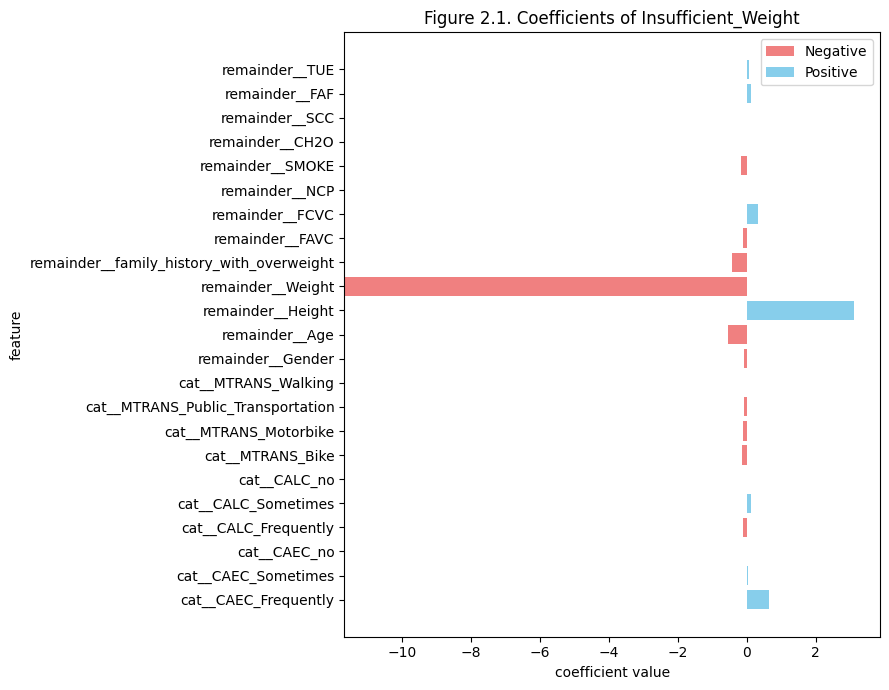

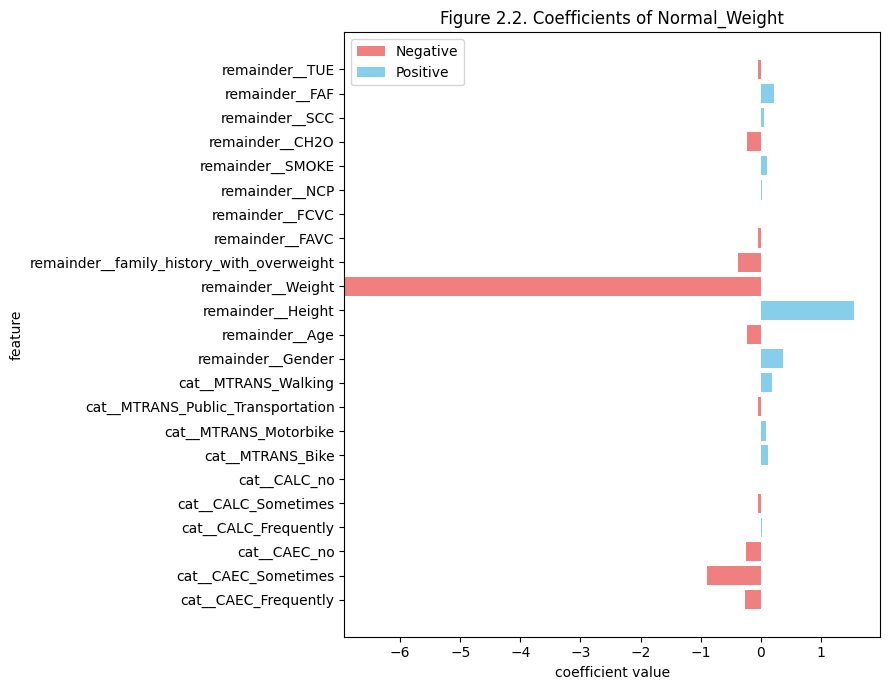

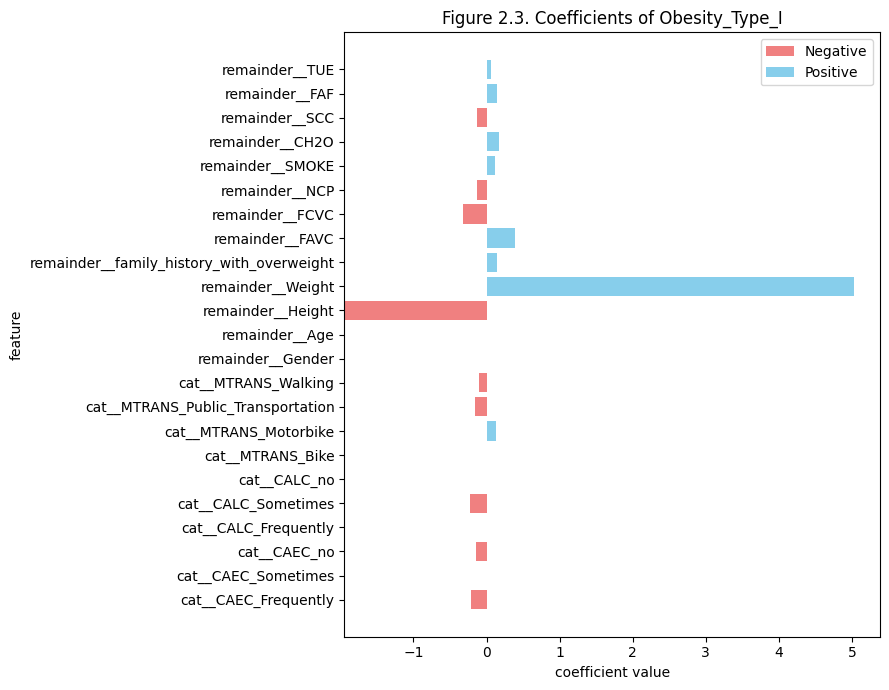

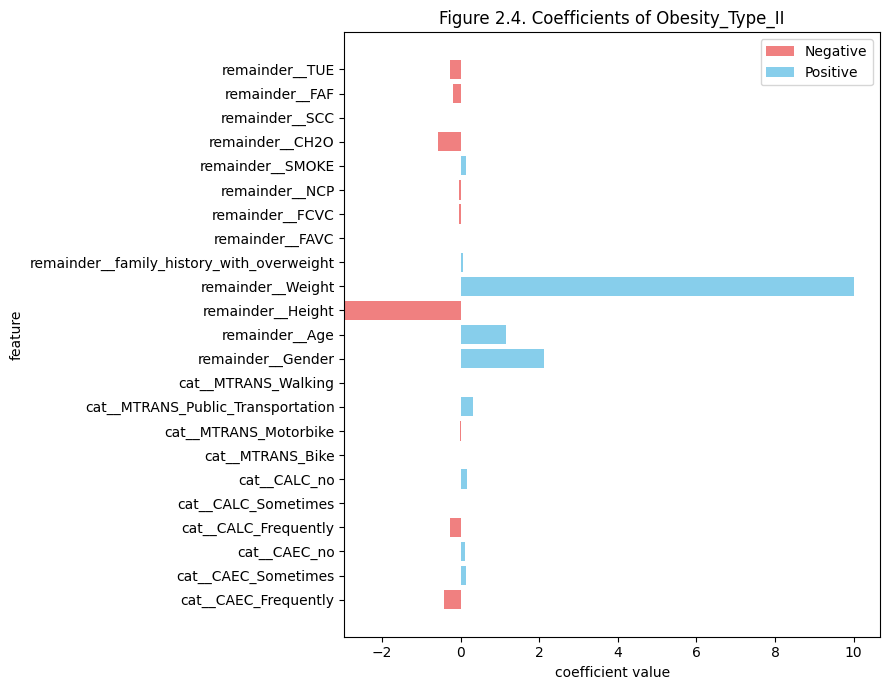

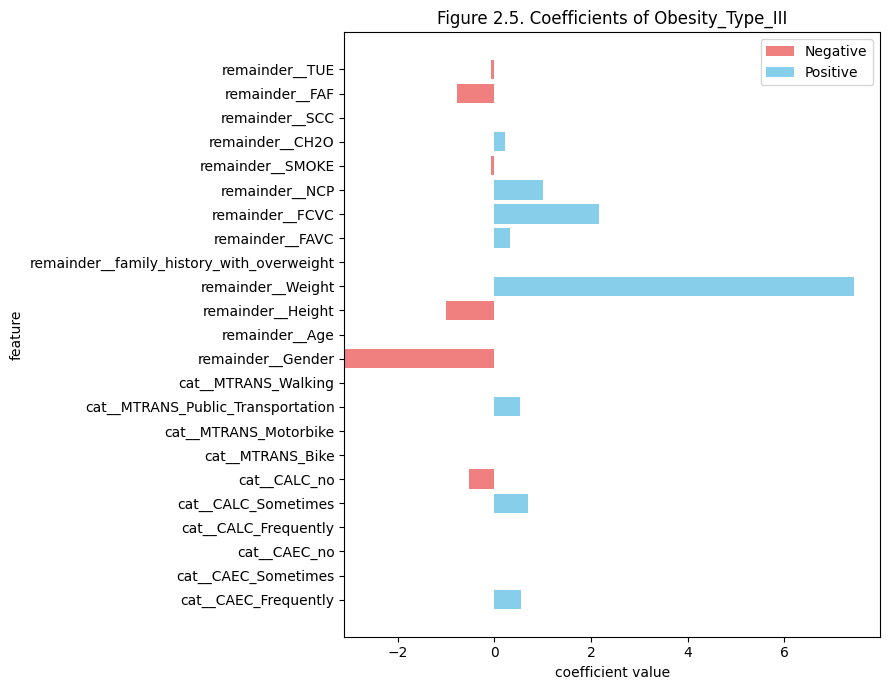

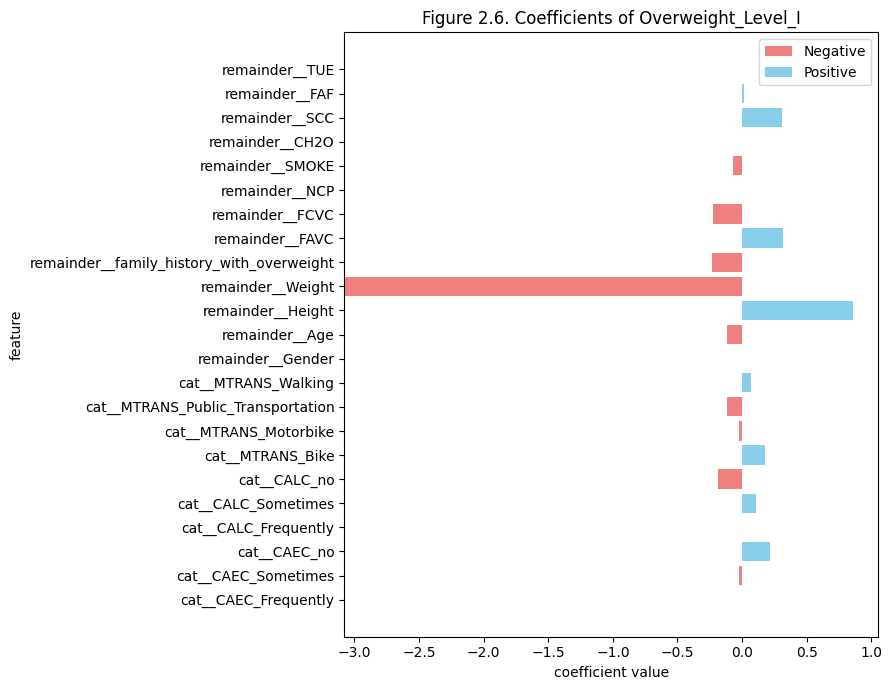

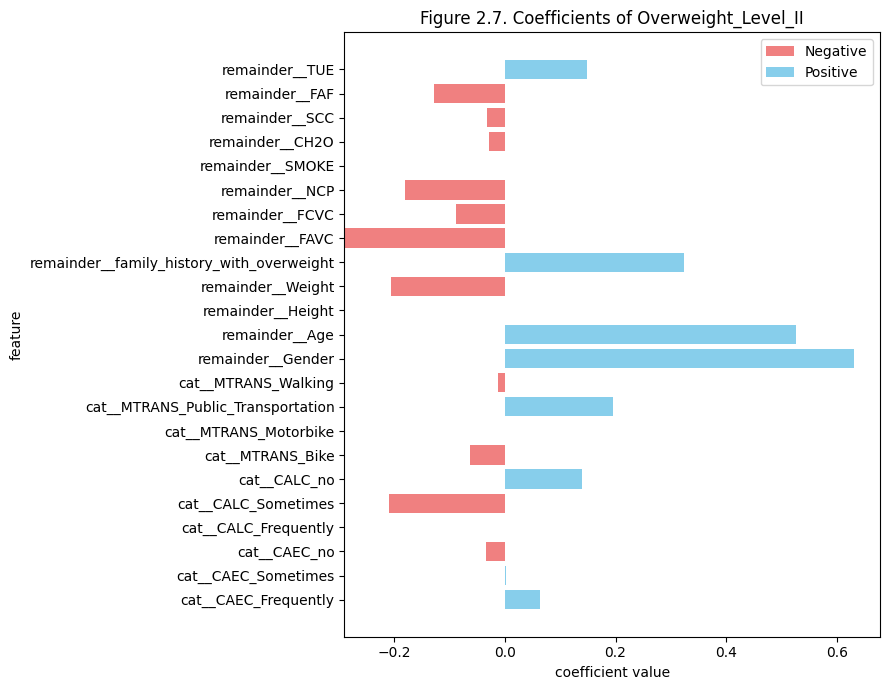

In [ ]:
classes = LR_grid_search.classes_
for i in range(len(classes)):
    visualize_coefs(LR_coefs[i], f"Figure 2.{i+1}. Coefficients of {classes[i]}")

### MODEL 2: Using Decision Trees

We follow similar pre-processing procedures as in Model 1, particularly with how we use one-hot-encoding and split our data into training and testing sets. However, note that in training this model, we split the dataset such that to 70% is used for training and 30% for testing. This decision is arbitrary.

In [ ]:
# Classify the features
binary_cols = ['Gender',"family_history_with_overweight","FAVC","SMOKE","SCC"]
numeric_cols = ["Age","Height","Weight","FCVC","NCP","CH2O","FAF","TUE"]
cat_cols = ["CAEC","CALC","MTRANS"]

# Encode the non-numeric features
for col in binary_cols:
  X[col] = LabelEncoder().fit_transform(X[col])

ct = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)],
    remainder='passthrough'
)

X_cont = ct.fit_transform(X).copy()
y_arr = y["NObeyesdad"].to_numpy()

# Perform a 70-30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_cont, y_arr, test_size=0.3, random_state=67
)

/tmp/ipython-input-3161271214.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = LabelEncoder().fit_transform(X[col])
/tmp/ipython-input-3161271214.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = LabelEncoder().fit_transform(X[col])
/tmp/ipython-input-3161271214.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

In [ ]:
# Train the model
decision_tree = DecisionTreeClassifier(criterion="gini", max_depth=4, min_samples_leaf=5)
decision_tree.fit(X_train, y_train)

# Predict labels of test set
y_pred = decision_tree.predict(X_test)

# Print out the classification report
print(f"Table 3.1. Summary of the score using Decision Tree Classifier.\n\n{classification_report(y_test, y_pred)}")

Table 3.1. Summary of the score using Decision Tree Classifier.

                     precision    recall  f1-score   support

Insufficient_Weight       0.87      0.97      0.91        89
      Normal_Weight       0.88      0.63      0.73        91
     Obesity_Type_I       0.89      0.66      0.76       106
    Obesity_Type_II       0.97      0.95      0.96        91
   Obesity_Type_III       1.00      0.99      0.99        96
 Overweight_Level_I       0.61      0.62      0.62        82
Overweight_Level_II       0.49      0.77      0.60        79

           accuracy                           0.80       634
          macro avg       0.81      0.80      0.80       634
       weighted avg       0.83      0.80      0.80       634



In an attempt to train a more accurate model, we consider varying the hyperparameter `max_depth` (with values between 1 to 14). As before, we use `GridSearch_CV` for this with $n = 5$ folds. We find that most accurate model has maximum depth of 10, with accuracy of 0.91. **This makes the decision tree model more accurate than the logistic regression model** (with a score of 0.83).

In [ ]:
# Grid search max_depth values from 1 to 14
param_grid = {'max_depth': range(1, 15)}
DT_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(criterion='gini', min_samples_leaf=5),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',

)

DT_grid_search.fit(X_train, y_train)
y_pred = DT_grid_search.predict(X_test)


# Print out optimal hyperparameter values with associated accuracy score.
print("Best max_depth:", DT_grid_search.best_params_['max_depth'])
print("Best CV accuracy:", DT_grid_search.best_score_)
print(f"\nTable 4.1. Summary of the score of the best estimator using Decision Tree Classifier.\n\n{classification_report(y_test, y_pred)}")

Best max_depth: 10
Best CV accuracy: 0.9167338524965644

Table 4.1. Summary of the score of the best estimator using Decision Tree Classifier.

                     precision    recall  f1-score   support

Insufficient_Weight       0.91      0.97      0.94        89
      Normal_Weight       0.79      0.85      0.82        91
     Obesity_Type_I       0.90      0.93      0.92       106
    Obesity_Type_II       0.94      0.96      0.95        91
   Obesity_Type_III       1.00      0.99      0.99        96
 Overweight_Level_I       0.88      0.78      0.83        82
Overweight_Level_II       0.94      0.86      0.90        79

           accuracy                           0.91       634
          macro avg       0.91      0.90      0.91       634
       weighted avg       0.91      0.91      0.91       634



The figure below visualizes the original model named `decision_tree` for the purposes of demonstration. (You may choose to visualize the model named `DT_grid_search`, which is the model identified to produce the most accurate predictions, by un-commenting the relevant code block.)

Note that in the visualizaton, for each node, if the data point meets the threshold, it will move to the left branch, otherwise it moves to the right branch. The terminal node it reaches determines its predicted class.


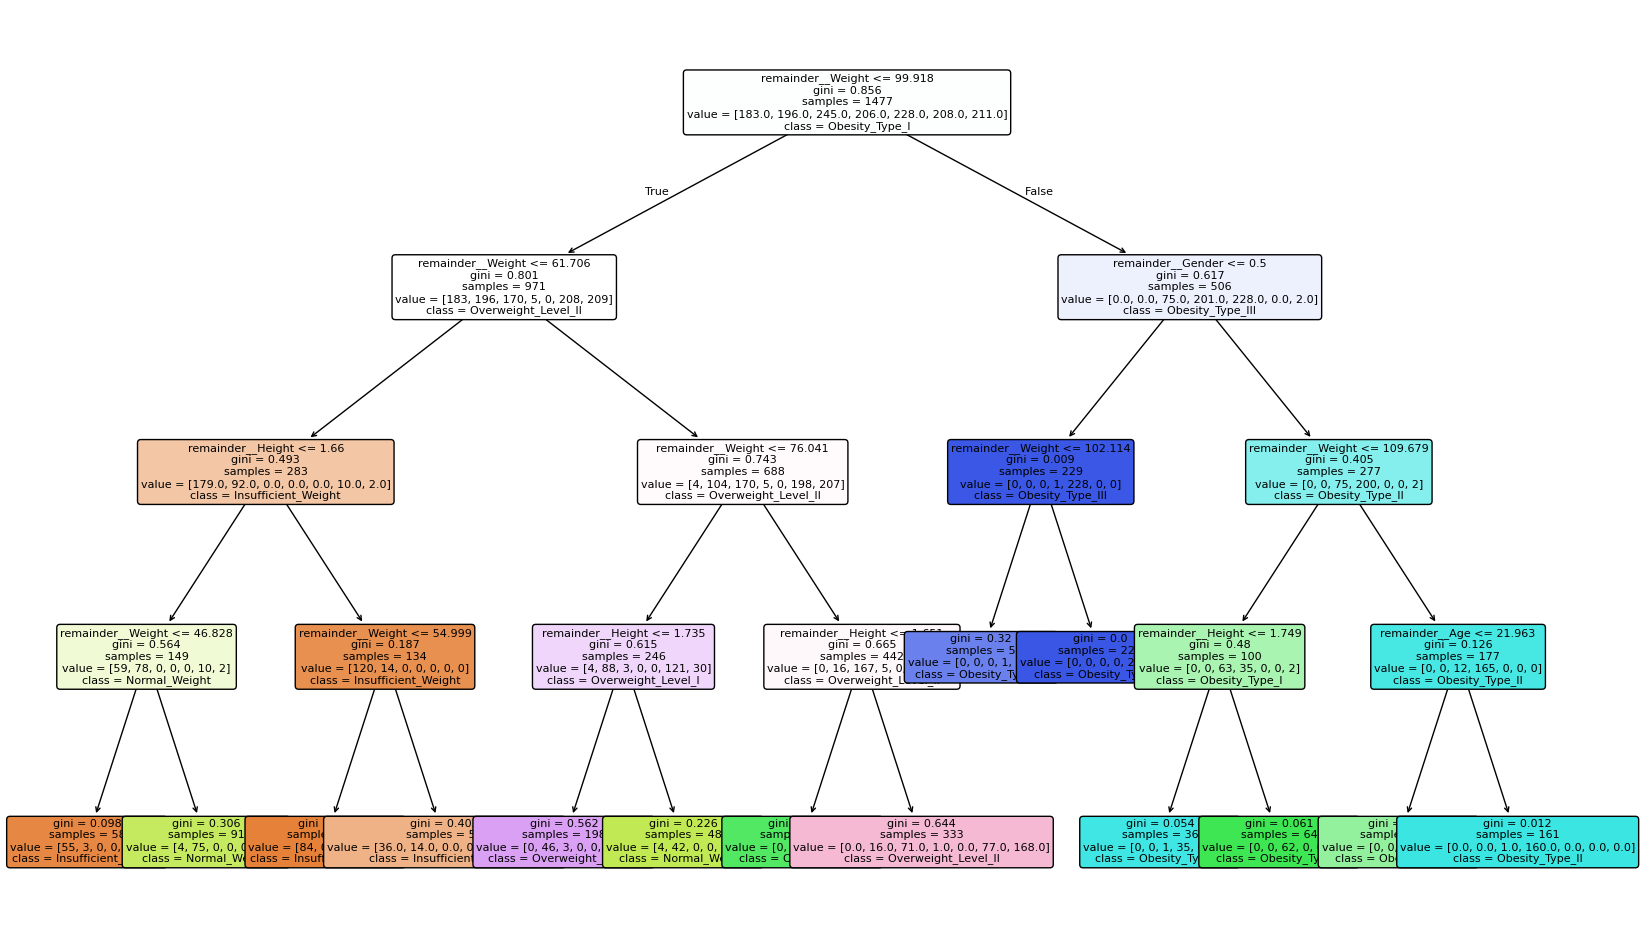

In [ ]:
feature_names = ct.get_feature_names_out()

plt.figure(figsize=(20,12))

# plot_tree(
#     DT_grid_search.best_estimator_,
#     feature_names=feature_names,
#     class_names=LabelEncoder().fit(y_arr).classes_,
#     filled=True,
#     rounded=True,
#     fontsize=8,
# )

plot_tree(
    decision_tree,
    feature_names=feature_names,
    class_names=LabelEncoder().fit(y_arr).classes_,
    filled=True,
    rounded=True,
    fontsize=8,
)


plt.show()

### Predictions

At this point, we demonstrate the predictive capacity of both models. The hidden function `predict_obesity_level` below takes in the characteristics of an individual and the model to be used to predict, and output the most likely classification for the individual. We know from before that the logistic regression model has an accuracy of 0.90 and the decision tree has an accuracy of 0.91.

You are encouraged to try different for the dictionary below.

In [ ]:
# @title
def predict_obesity_level(individual, model):
    transformed = {}

    for col in binary_cols:
        if (individual[col] == "yes" or individual[col] == "Female"):
            transformed[f"remainder__{col}"] = 1
        else:
            transformed[f"remainder__{col}"] = 0

    for col in numeric_cols:
        transformed[f"remainder__{col}"] = individual[col]

    for resp in ["Frequently", "Sometimes", "no"]:
        transformed[f"cat__CAEC_{resp}"] = (1 if individual["CAEC"] == resp else 0)
        transformed[f"cat__CALC_{resp}"] = (1 if individual["CALC"] == resp else 0)
    for resp in ["Bike", "Motorbike", "Public_Transportation", "Walking"]:
        transformed[f"cat__MTRANS_{resp}"] = (1 if individual["MTRANS"] == resp else 0)

    # turn into a vector and predict
    X = np.array([transformed[col] for col in ct.get_feature_names_out()]).reshape(1, -1)
    return model.predict(X)


In [ ]:
model = LR_grid_search.best_estimator_
# model = DT_grid_search.best_estimator_

individual = {
    "Gender": "Male",
    "Age": 21.0,
    "Height": 1.62,
    "Weight": 64.0,
    "family_history_with_overweight": "yes",    # Has a family member suffered or suffers from overweight?
    "FAVC": "no",                               # Do you eat high caloric food frequently?
    "FCVC": 2.0,                                # Do you usually eat vegetables in your meals?
    "NCP": 3.0,                                 # How many main meals do you have daily?
    "CAEC": "Sometimes",                        # Do you eat any food between meals? (Sometimes, Frequently, no)
    "SMOKE": "no",                              # Do you smoke?
    "CH2O": 2.0,                                # How much water do you drink daily?
    "SCC": "no",                                # Do you monitor the calories you eat daily?
    "FAF": 0.0,                                 # How often do you have physical activity?
    "TUE": 1.0,                                 # How much time do you use technological devices such as cell phone, videogames, television, computer and others?
    "CALC": "no",                               # How often do you drink alcohol? (Sometimes, Frequently, no)
    "MTRANS": "Bike"           # Which transportation do you usually use? (Bike, Motorbike, Public_Transportation, Walking)
}

predict_obesity_level(individual, model)

array(['Overweight_Level_I'], dtype=object)